# Data processing Fair Neural Sheaf Diffusion

In [1]:
import sys
from pathlib import Path
import os
import json
import optuna
import argparse

import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from adjustText import adjust_text
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Arc

sys.path.append('..')
from utils.constants import models, datasets

/home/arturo_perez/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


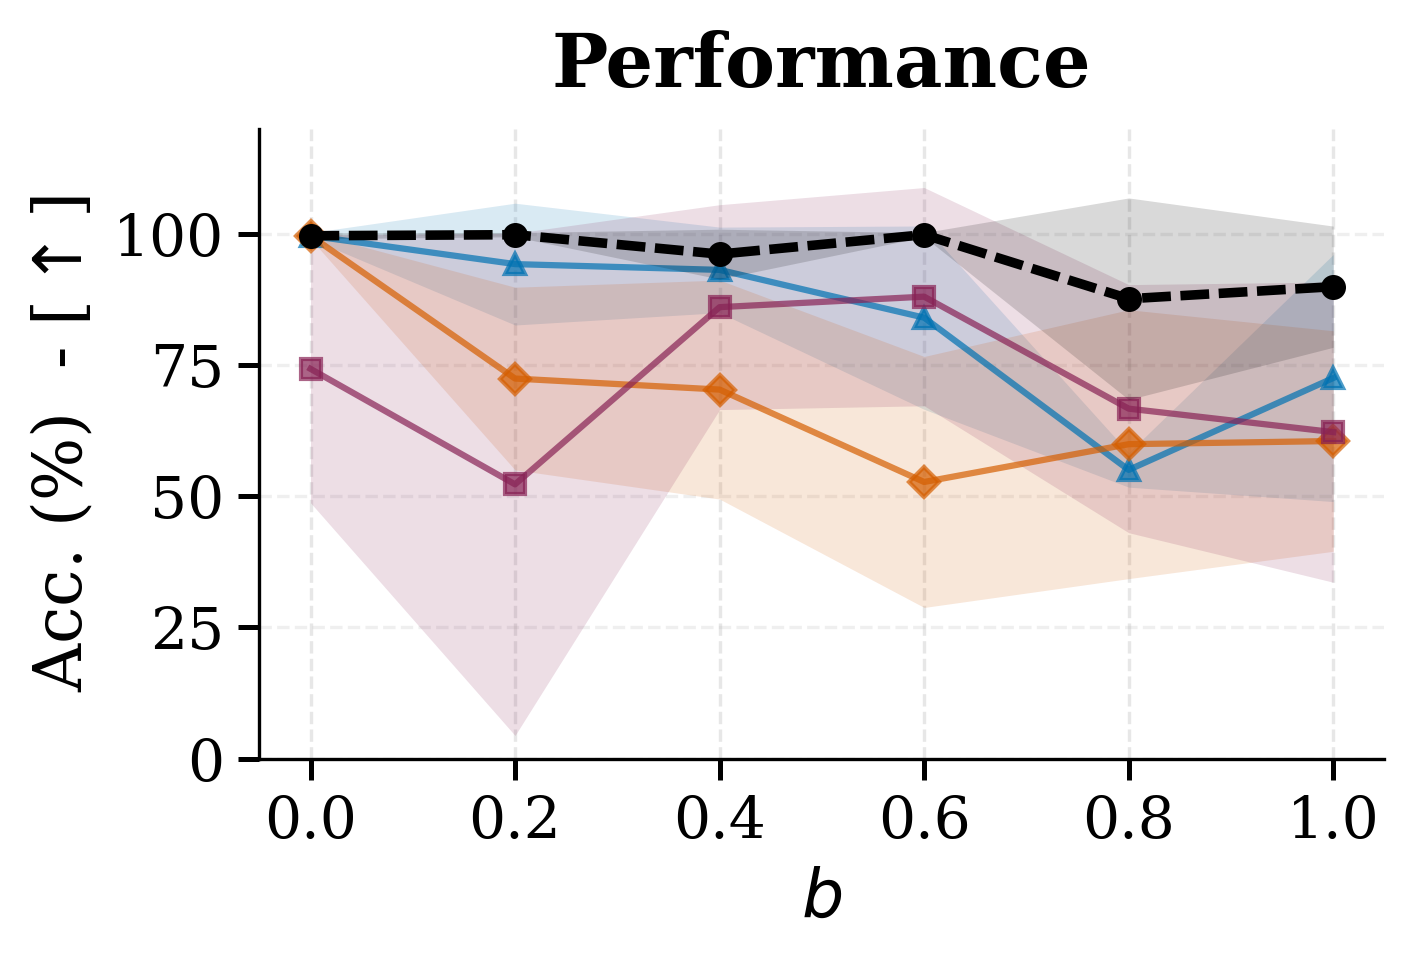

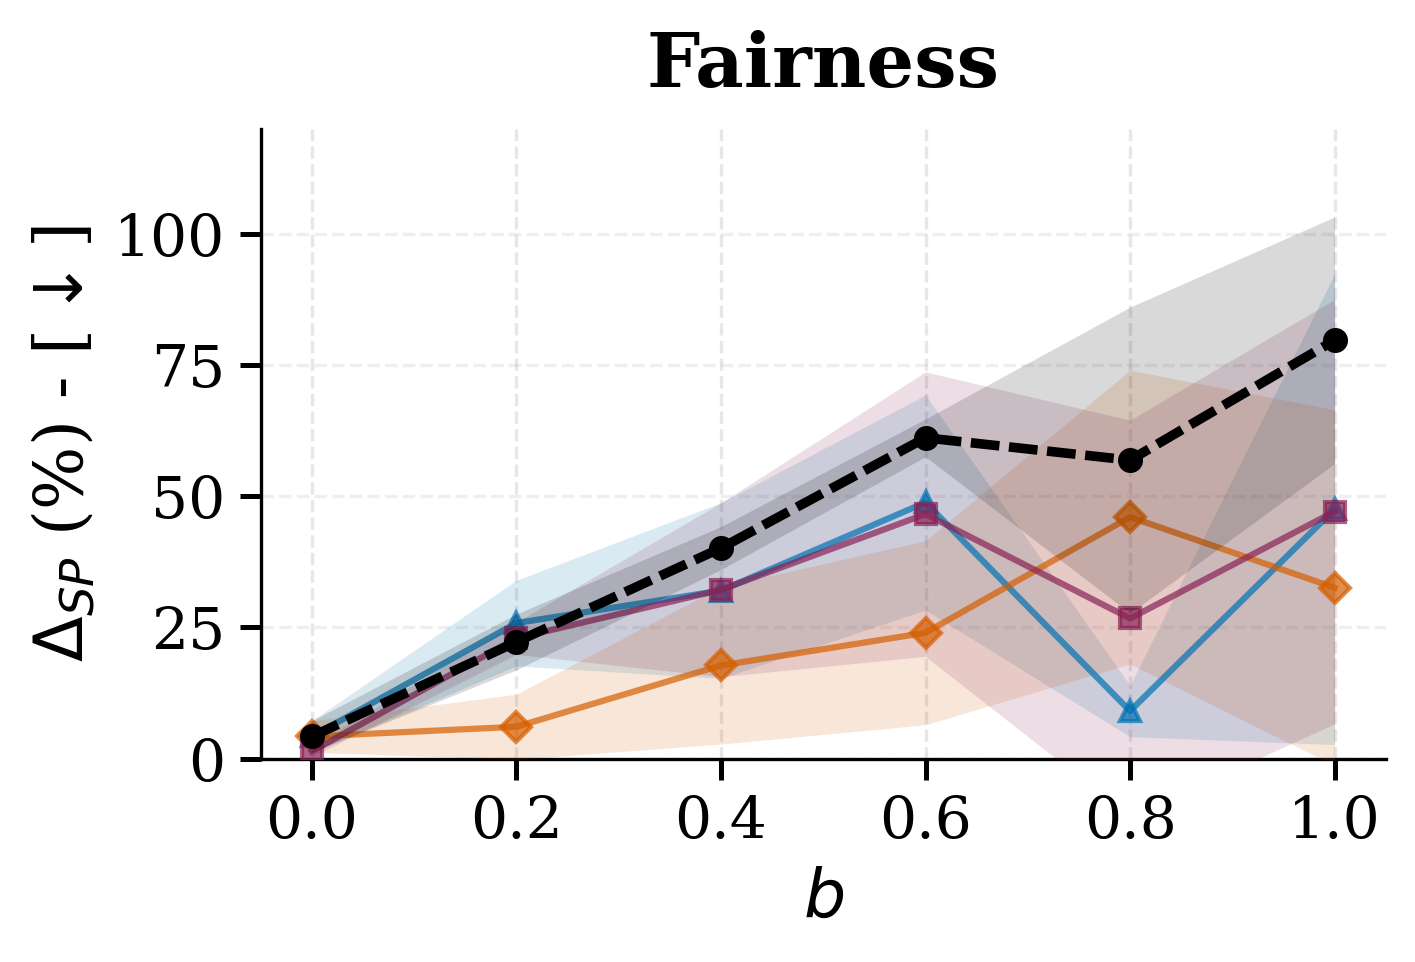

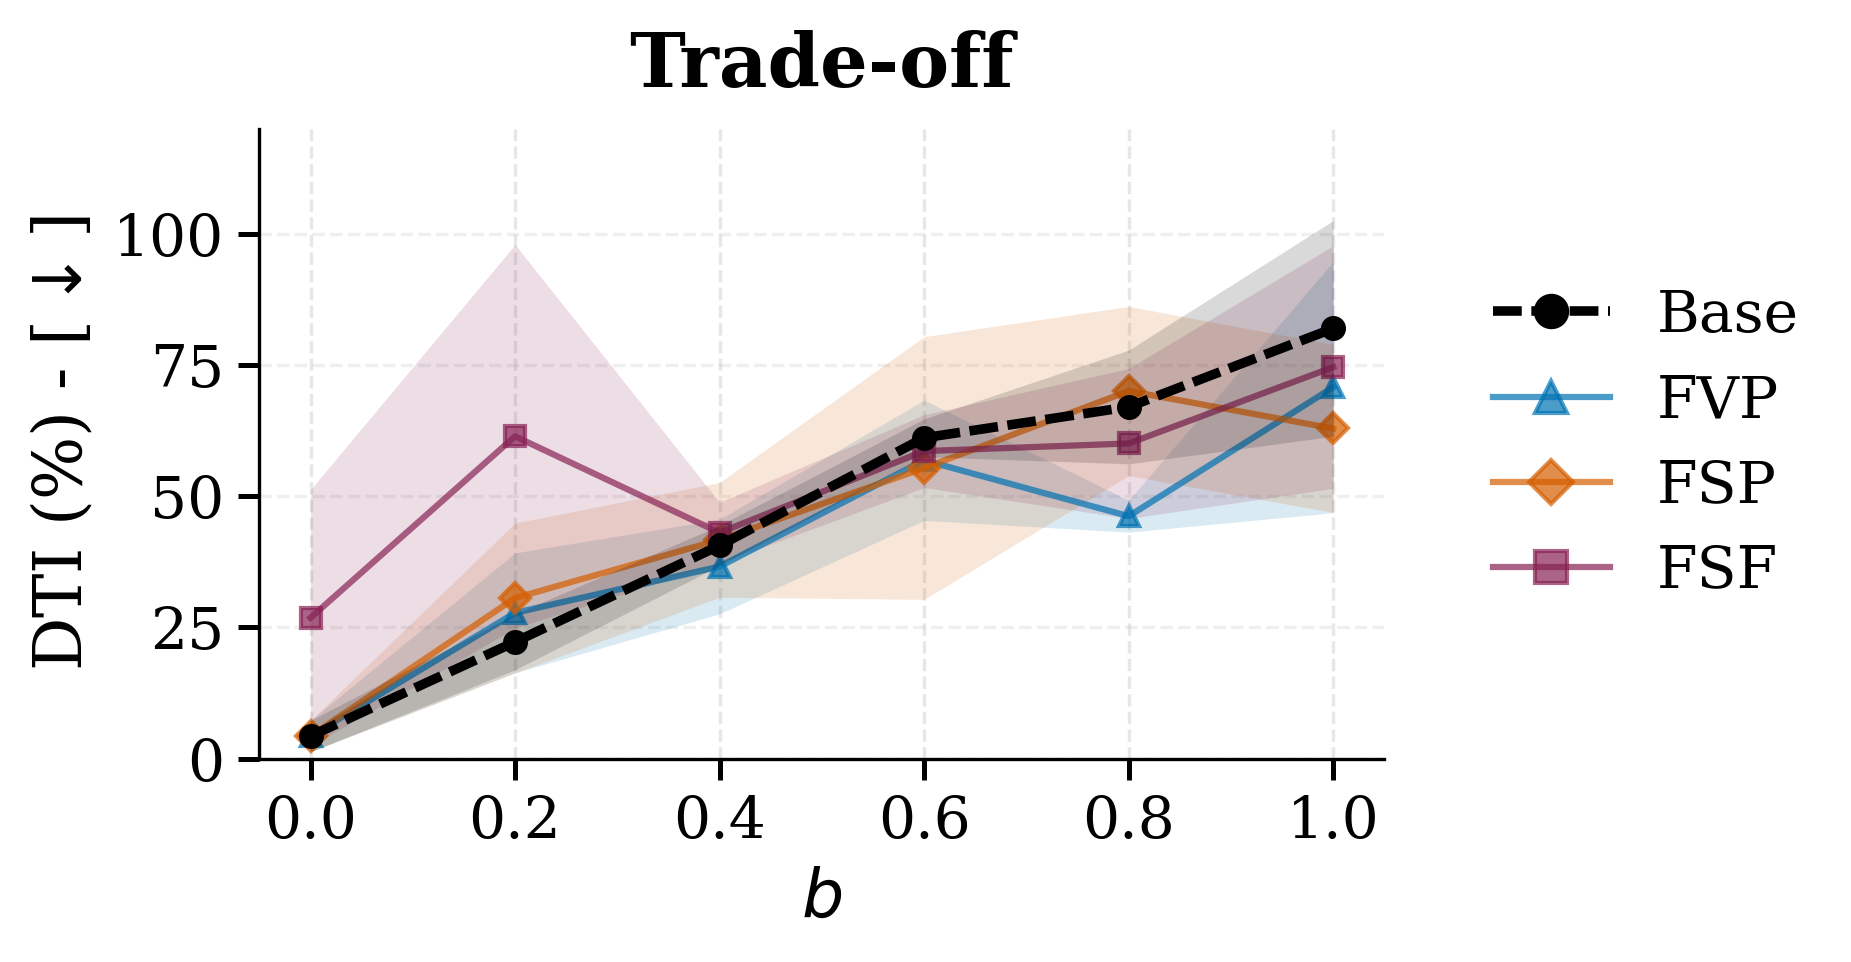

In [2]:
RESULTS_DIR = "results/filter/synthetic"
FIGS_DIR = "results/filter/figs"
MODELS_OF_INTEREST = ['gen', 'vectgen', 'specgen', 'polygen']

if not os.path.exists(FIGS_DIR):
    os.makedirs(FIGS_DIR)

MODEL_CONFIG = {
    'gen':     {
        'label': 'Base', 
        'color': '#000000', 
        'marker': 'o', 
        'dashes': (3, 1), 
        'linewidth': 2.3, 
        'alpha': 1.0, 
        'zorder': 10
    },
    'vectgen': {
        'label': 'FVP',  
        'color': '#0072B2', 
        'marker': '^', 
        'dashes': None,     
        'linewidth': 1.5, 
        'alpha': 0.7, 
        'zorder': 5
    },
    'specgen': {
        'label': 'FSP',  
        'color': '#D55E00', 
        'marker': 'D', 
        'dashes': None,     
        'linewidth': 1.5, 
        'alpha': 0.7, 
        'zorder': 5
    },
    'polygen': {
        'label': 'FSF',  
        'color': '#882255', 
        'marker': 's', 
        'dashes': None,     
        'linewidth': 1.5, 
        'alpha': 0.7, 
        'zorder': 5
    },
}

METRICS_CONFIG = [
    {'key': 'acc',  'label': 'Accuracy',      'ylabel': r'Acc. (%)  - [$\uparrow$]',           'title': 'Performance', 'fname': 'synthetic_acc'},
    {'key': 'ind',  'label': 'Stat. Parity',  'ylabel': r'$\Delta_{SP}$ (%) - [$\downarrow$]', 'title': 'Fairness',    'fname': 'synthetic_ind'},
    {'key': 'dist', 'label': 'Distance',      'ylabel': r'DTI (%) - [$\downarrow$]',      'title': 'Trade-off',   'fname': 'synthetic_dist'}
]

plt.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 14,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18
})

data_store = {m: {} for m in MODELS_OF_INTEREST}

if os.path.exists(RESULTS_DIR):
    for filename in os.listdir(RESULTS_DIR):
        if not filename.endswith('.json'): continue
        
        model_name = None
        for m in MODELS_OF_INTEREST:
            if filename.startswith(f'res_{m}'):
                model_name = m
                break
        
        if model_name is None: continue

        try:
            param_val = (float(filename[-8:-5])-0.5)*2
        except ValueError:
            continue
        
        with open(os.path.join(RESULTS_DIR, filename), 'r') as f:
            content = json.load(f)
        
        if param_val not in data_store[model_name]:
            data_store[model_name][param_val] = {
                'mean': {'acc': [], 'ind': [], 'dist': []},
                'std':  {'acc': [], 'ind': [], 'dist': []}
            }
        
        summary = content.get('summary', {})
        
        data_store[model_name][param_val]['mean']['acc'].append(summary.get('mean_test_acc', 0))
        data_store[model_name][param_val]['mean']['ind'].append(summary.get('mean_test_ind', 0))
        data_store[model_name][param_val]['mean']['dist'].append(summary.get('mean_test_dist', 0))

        data_store[model_name][param_val]['std']['acc'].append(summary.get('std_test_acc', 0))
        data_store[model_name][param_val]['std']['ind'].append(summary.get('std_test_ind', 0))
        data_store[model_name][param_val]['std']['dist'].append(summary.get('std_test_dist', 0))

def plot_metric(metric_meta, show_legend=False):
    fig = plt.figure(figsize=(5, 3), dpi=300)
    
    ax = fig.add_axes([0.18, 0.18, 0.75, 0.7])
    
    metric_key = metric_meta['key']
    
    for model in MODELS_OF_INTEREST:
        if not data_store[model]: continue
        
        cfg = MODEL_CONFIG[model]
        params = sorted(data_store[model].keys())
        if not params: continue
        
        means = []
        stds = []
        
        for p in params:
            m_vals = data_store[model][p]['mean'][metric_key]
            s_vals = data_store[model][p]['std'][metric_key]
            
            if m_vals:
                means.append(np.mean(m_vals)*100)
                stds.append(np.mean(s_vals)*100)
            else:
                means.append(0)
                stds.append(0)
            
        means = np.array(means)
        stds = np.array(stds)
        
        plot_kwargs = {
            'label': cfg['label'],
            'color': cfg['color'],
            'marker': cfg['marker'],
            'markersize': 5,
            'linewidth': cfg['linewidth'],
            'alpha': cfg['alpha'],
            'zorder': cfg['zorder']
        }
        
        if cfg['dashes']:
            plot_kwargs['dashes'] = cfg['dashes']
        else:
            plot_kwargs['linestyle'] = '-'
        
        ax.plot(params, means, **plot_kwargs)
        
        ax.fill_between(params, means - stds, means + stds, 
                        color=cfg['color'], 
                        alpha=0.15, 
                        linewidth=0,
                        zorder=cfg['zorder'] - 1)

    ax.tick_params(axis='both', which='major', direction='out', length=5, width=1.2)
    ax.tick_params(axis='y', which='minor', direction='out', length=3)
    
    ax.set_xlabel(r"$b$") 
    ax.set_ylabel(metric_meta['ylabel'])
    ax.set_ylim((0.0, 120.0))
    ax.set_title(metric_meta['title'], fontweight='bold', pad=10)
    
    ax.grid(True, which='both', axis='y', ls='--', alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_legend:
        ax.legend(loc='center left', 
                  bbox_to_anchor=(1.05, 0.5),
                  ncol=1, 
                  frameon=False,
                  fontsize=14,
                  markerscale=1.5)
    
    save_path = os.path.join(FIGS_DIR, f"{metric_meta['fname']}.pdf")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_metric(METRICS_CONFIG[0], show_legend=False)
plot_metric(METRICS_CONFIG[1], show_legend=False)
plot_metric(METRICS_CONFIG[2], show_legend=True)

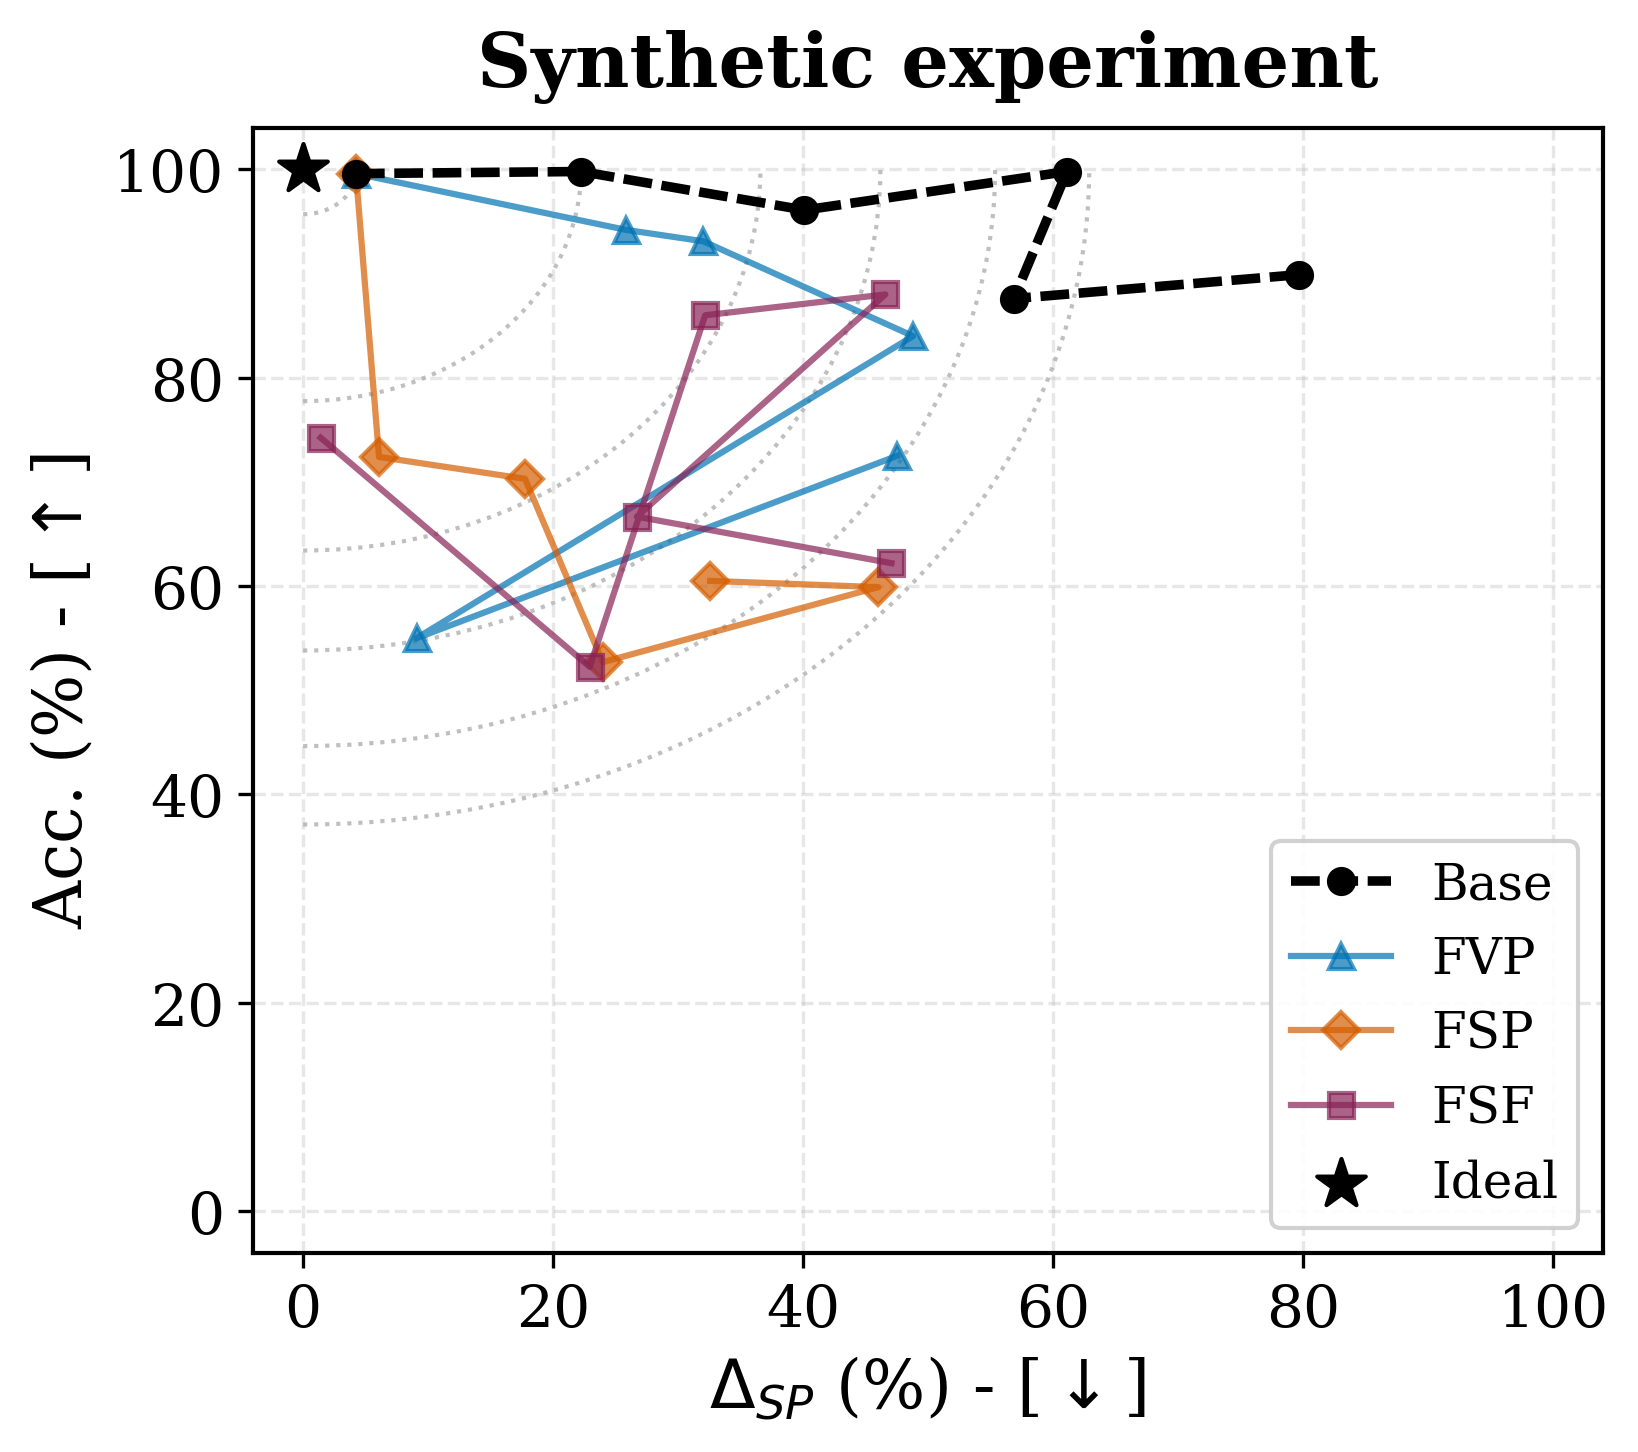

In [3]:
def plot_accuracy_fairness_tradeoff(show_legend=True):
    fig = plt.figure(figsize=(6, 5), dpi=300)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])

    all_params = set()
    dti_by_param = {}

    for model in MODELS_OF_INTEREST:
        if not data_store[model]: continue
        for p in data_store[model].keys():
            all_params.add(p)
            if p not in dti_by_param:
                dti_by_param[p] = []
            
            m_dti = data_store[model][p]['mean']['dist']
            if m_dti:
                dti_by_param[p].append(np.mean(m_dti))

    sorted_params = sorted(list(all_params))
    
    for p in sorted_params:
        if dti_by_param[p]:
            min_dti = min(dti_by_param[p])*100
            arc = Arc((0,100), width=min_dti*2, height=min_dti*2, 
                      theta1=-90, theta2=0, 
                      color='gray', linestyle=':', linewidth=1.0, alpha=0.5)
            ax.add_patch(arc)

    for model in MODELS_OF_INTEREST:
        if not data_store[model]: continue
        
        cfg = MODEL_CONFIG[model]
        params = sorted(data_store[model].keys())
        if not params: continue
        
        acc_means = []
        ind_means = []
        
        for p in params:
            m_acc = data_store[model][p]['mean']['acc']
            m_ind = data_store[model][p]['mean']['ind']
            
            if m_acc and m_ind:
                acc_means.append(np.mean(m_acc))
                ind_means.append(np.mean(m_ind))
        
        acc_means = np.array(acc_means)*100
        ind_means = np.array(ind_means)*100
        
        plot_kwargs = {
            'label': cfg['label'],
            'color': cfg['color'],
            'marker': cfg['marker'],
            'markersize': 6,
            'linewidth': cfg['linewidth'],
            'alpha': cfg['alpha'],
            'zorder': cfg['zorder']
        }
        
        if cfg['dashes']:
            plot_kwargs['dashes'] = cfg['dashes']
        else:
            plot_kwargs['linestyle'] = '-'
            
        ax.plot(ind_means, acc_means, **plot_kwargs)

    ax.scatter([0], [100], c='black', marker='*', s=150, zorder=20, label='Ideal')

    ax.set_ylabel(r'Acc. (%) - [$\uparrow$]')
    ax.set_xlabel(r'$\Delta_{SP}$ (%) - [$\downarrow$]')
    ax.set_title('Synthetic experiment', fontweight='bold', pad=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_xlim(left=-4, right=104)
    ax.set_ylim(bottom=-4, top=104)

    ax.grid(True, linestyle='--', alpha=0.3)

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        # Filter duplicate labels if any
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), 
                  loc='lower right', 
                  frameon=True,
                  framealpha=0.9,
                  fontsize=12)
        
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    save_path = os.path.join(FIGS_DIR, "synthetic_tradeoff.pdf")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_accuracy_fairness_tradeoff(show_legend=True)

[ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.3  1.4
  1.5  1.6  1.7  1.8  2.   2.5  3.   4.   5.   6.   7.   8.   9.  10.
 20.  21.  22.  23.  24.  31.  32.  33.  34.  35.  36.  37.  38.  39.
 39.2]
[ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.3  1.4
  1.5  1.6  1.7  1.8  2.   2.5  8.  31.  32.  40.  53.  58. ]
[0.  0.1 0.3 0.4 0.5 0.6 0.7 0.9 1.  1.1 3. ]


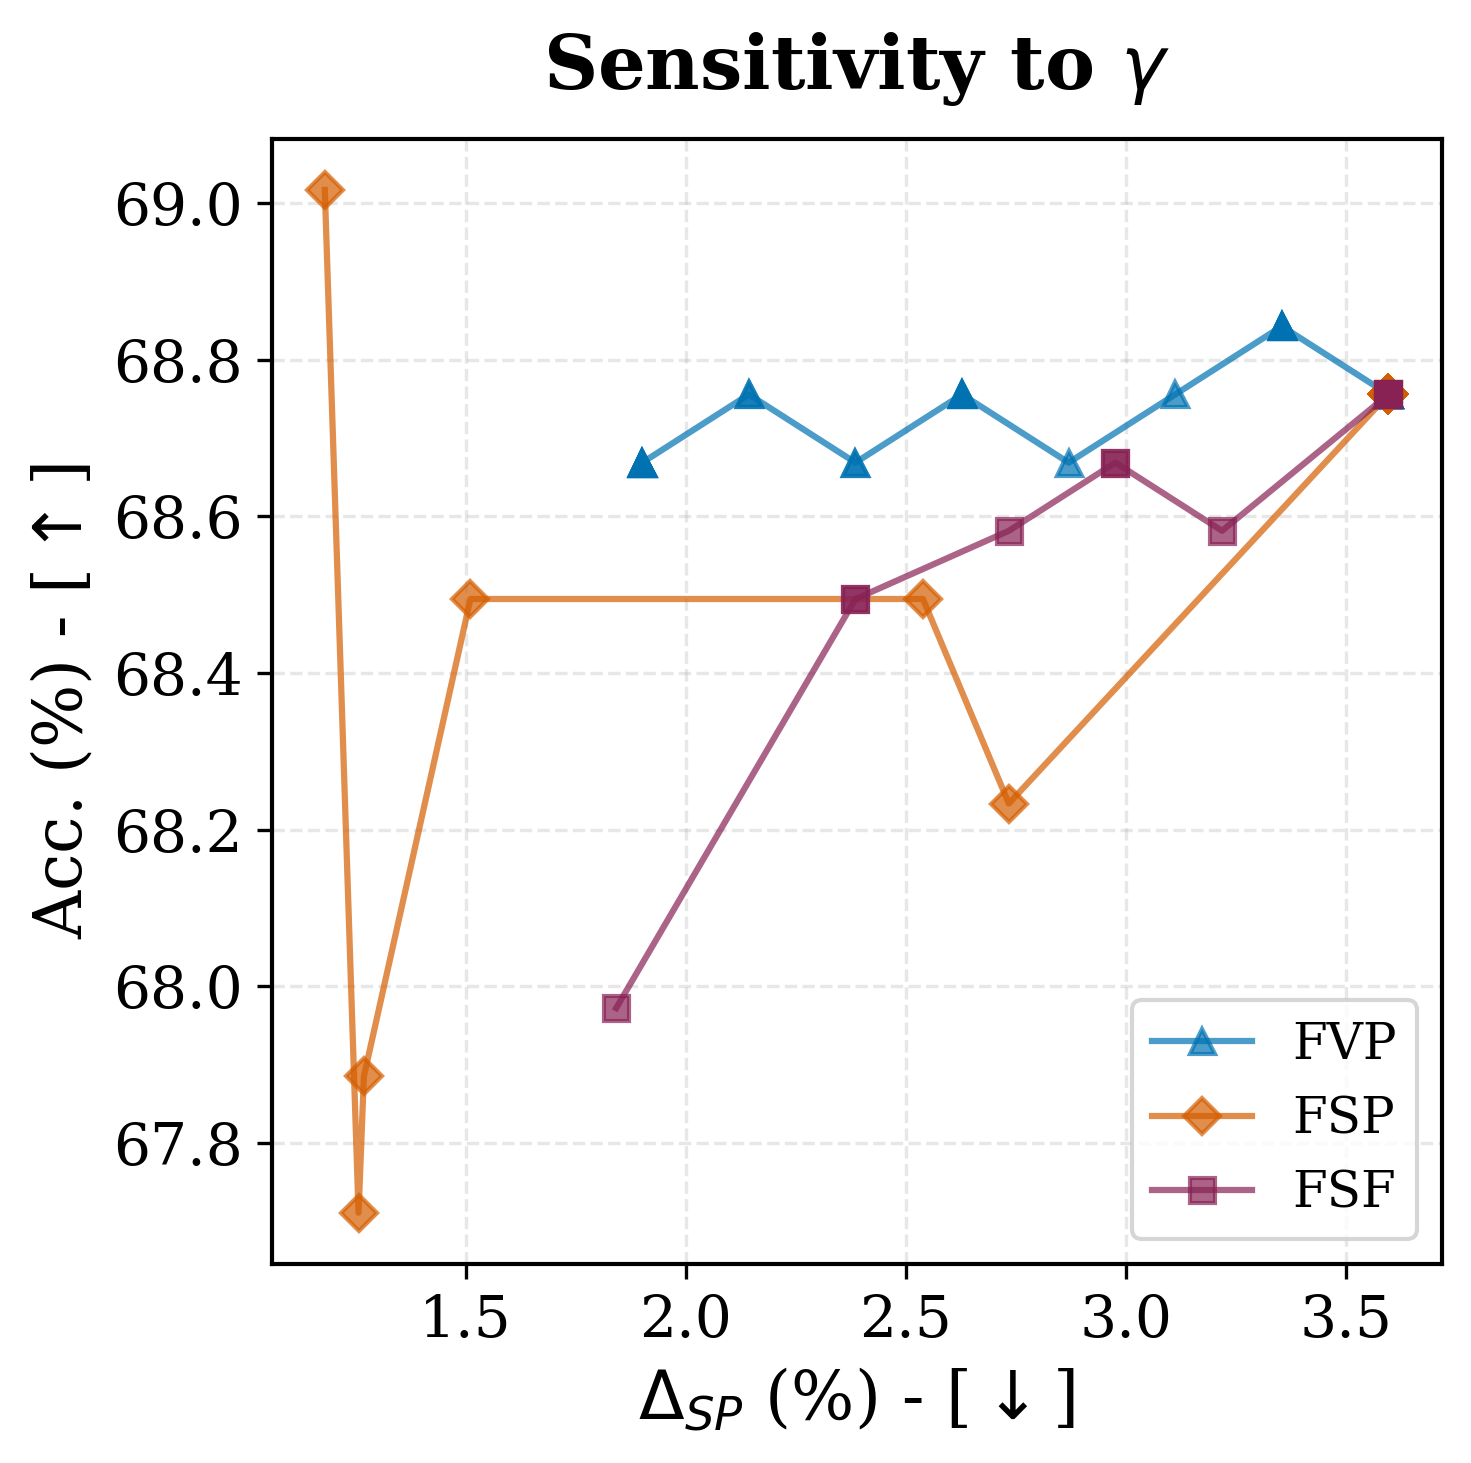

In [4]:
RESULTS_DIR = "results/filter/tradeoff"
FIGS_DIR = "results/filter/figs"
MODELS_OF_INTEREST = ['vectdia', 'specdia', 'polydia']

if not os.path.exists(FIGS_DIR):
    os.makedirs(FIGS_DIR)

MODEL_CONFIG = {
    'vectdia': {
        'label': 'FVP',  
        'color': '#0072B2', 
        'marker': '^', 
        'dashes': None,     
        'linewidth': 1.5, 
        'alpha': 0.7, 
        'zorder': 5,
        'param': 'reg_strength'
    },
    'specdia': {
        'label': 'FSP',  
        'color': '#D55E00', 
        'marker': 'D', 
        'dashes': None,     
        'linewidth': 1.5, 
        'alpha': 0.7, 
        'zorder': 5,
        'param': 'f'
    },
    'polydia': {
        'label': 'FSF',  
        'color': '#882255', 
        'marker': 's', 
        'dashes': None,     
        'linewidth': 1.5, 
        'alpha': 0.7, 
        'zorder': 5,
        'param': 'gamma'
    },
}

METRICS_CONFIG = [
    {'key': 'acc',  'label': 'Accuracy',      'ylabel': 'Test Accuracy',          'title': 'Performance vs Parameter', 'fname': 'tradeoff_acc_param'},
    {'key': 'ind',  'label': 'Stat. Parity',  'ylabel': r'Independence ($\Delta_{SP}$)', 'title': 'Fairness vs Parameter',    'fname': 'tradeoff_ind_param'},
]

plt.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",
    "font.size": 14,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18
})

data_store = {m: {} for m in MODELS_OF_INTEREST}

if os.path.exists(RESULTS_DIR):
    for filename in os.listdir(RESULTS_DIR):
        if 'nba' in filename: continue
        if 'gen' in filename: continue
        
        parts = filename.replace('.json', '').split('_')
        model_name = parts[0]
        
        val_str = parts[-1]
        param_val = float(val_str)
        
        target_param = MODEL_CONFIG[model_name]['param']
        
        with open(os.path.join(RESULTS_DIR, filename), 'r') as f:
            content = json.load(f)
        try:
            data_store[model_name][param_val] = {
                'acc': content['test']['acc']*100, 'ind': content['test']['ind']*100
            }
        except:
            pass

fig = plt.figure(figsize=(6, 5), dpi=300)
ax = fig.add_axes([0.15, 0.15, 0.65, 0.75])

for model in MODELS_OF_INTEREST:
    
    cfg = MODEL_CONFIG[model]
    params = sorted(data_store[model].keys())

    accs = []
    inds = []
    
    for p in params:
        acc_vals = data_store[model][p]['acc']
        ind_vals = data_store[model][p]['ind']
        
#        accs.append(np.mean(acc_vals) if acc_vals else 0)
#        inds.append(np.mean(ind_vals) if ind_vals else 0)
        accs.append(acc_vals)
        inds.append(ind_vals)
        
        
    accs = np.array(accs)
    inds = np.array(inds)

    indices = np.concatenate([inds <= np.minimum.accumulate(inds)])

    print(np.array(params)[indices])
    
    accs = accs[indices]
    inds = inds[indices]
    
    plot_kwargs = {
        'label': cfg['label'],
        'color': cfg['color'],
        'marker': cfg['marker'],
        'markersize': 6,
        'linewidth': cfg['linewidth'],
        'alpha': cfg['alpha'],
        'zorder': cfg['zorder']
    }
    
    if cfg['dashes']:
        plot_kwargs['dashes'] = cfg['dashes']
    else:
        plot_kwargs['linestyle'] = '-'
        
    ax.plot(inds, accs, **plot_kwargs)
    
#    if len(inds) > 1:
#        
#        # Mark the direction of the parameter increase
#        ax.annotate('', xy=(inds[-1], accs[-1]), 
#                    xytext=(inds[-2], accs[-2]),
#                    arrowprops=dict(arrowstyle="->", color=cfg['color'], lw=1.5))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)

ax.set_xlabel(r'$\Delta_{SP}$ (%) - [$\downarrow$]')
ax.set_ylabel(r'Acc. (%) - [$\uparrow$]')
ax.set_title(r'Sensitivity to $\gamma$', fontweight='bold', pad=12)

ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.legend(loc='best', frameon=True, fontsize=12)

save_path = os.path.join(FIGS_DIR, "tradeoff.pdf")
# plt.xlim((0, 5))
plt.savefig(save_path, bbox_inches='tight')
plt.show()

In [5]:
MODELS_OF_INTEREST

['vectdia', 'specdia', 'polydia']

In [6]:
path_results = Path('results/filter/experiment')
folder_results = os.listdir(path_results)
results_dict = {dataset: {} for dataset in datasets}

for dataset in ['german', 'compass', 'pokec_n', 'pokec_z', 'nba']:
    for model in models:
        name = f"{model}_{dataset}_final_run.json"
        if name in folder_results:
            with open(path_results / name, 'r') as f:
                tmp = json.load(f)
                results_dict[dataset][model] = tmp
            

In [7]:
metrics_config = {
    'acc':    {'json_key': 'acc', 'label': r'Acc.',           'minimize': False},
    'balacc': {'json_key': 'balacc',   'label': 'Bal. Acc.',      'minimize': False},
    'auc':    {'json_key': 'auc',      'label': 'AUC',            'minimize': False},
    'f1':     {'json_key': 'f1',       'label': 'F1',             'minimize': False},
    'ind':    {'json_key': 'ind',      'label': r'$\Delta_{SP}$', 'minimize': True},
    'sep':    {'json_key': 'sep',      'label': r'$\Delta_{EO}$', 'minimize': True},
    'con':    {'json_key': 'con',      'label': r'Con. ($10$)', 'minimize': False},
    'dti':    {'json_key': 'dti',      'label': 'DTI',            'minimize': True}
}

metrics_order = ['acc', 'f1', 'auc', 'ind', 'sep', 'con', 'dti']
prefixes_to_filter = ['rw', 'fd', 'us', 'ro']
filter_metric_criteria = 'balacc'

model_map = {
    'vectdia': 'Diag-FVP',
    'vectbun': 'O(d)-FVP',
    'vectgen': 'Gen-FVP',
    'specdia': 'Diag-FSP',
    'specbun': 'O(d)-FSP',
    'specgen': 'Gen-FSP',
    'polydia': 'Diag-FSF',
    'polybun': 'O(d)-FSF',
    'polygen': 'Gen-FSF',
    'dia': 'Diag-NSD',
    'bun': 'O(d)-NSD',
    'gen': 'Gen-NSD',
    'gcn': 'GCN',
    'gat': 'GAT',
    'sage': 'GraphSAGE',
    'h2gcn': 'H2GCN',
    'fd_gcn': 'Fair Drop',
    'fd_gat': 'Fair Drop',
    'fd_sage': 'Fair Drop',
    'fd_h2gcn': 'Fair Drop',
    'us_gcn': 'Undersampling',
    'us_gat': 'Undersampling',
    'us_sage': 'Undersampling',
    'us_h2gcn': 'Undersampling',
    'fairgnn': 'FairGNN',
    'fairsin': 'FairSIN',
    'nifty': 'NIFTY',
    'logreg': 'Log. Reg.',
    'xgb': 'XGBoost',
    'lgbm': 'LightGBM',
    'mlp': 'MLP',
    'rw_logreg': 'Reweighting',
    'rw_xgb': 'Reweighting',
    'rw_lgbm': 'Reweighting',
    'adversarial': 'adv-MLP',
    'ro_logreg': 'Rej. Opt.',
    'ro_xgb': 'Rej. Opt.',
    'ro_lgbm': 'Rej. Opt.',
}

models_display_order = list(dict.fromkeys(model_map.values()))

for dataset_name, models_data in results_dict.items():
    if not models_data:
        continue
    
    print(f"\n%%% Table for Dataset: {dataset_name} %%%")

    family_scores = {p: {'score': -float('inf'), 'model': None} for p in prefixes_to_filter}
    criteria_json_key = metrics_config.get(filter_metric_criteria, {}).get('json_key', filter_metric_criteria)

    for model_name, content in models_data.items():
        kfold = content.get('kfold_metrics')
        if not kfold or not isinstance(kfold, dict):
            continue
            
        means = kfold.get('avg_test_results', {})
        score = means.get(criteria_json_key, -float('inf'))
        
        for prefix in prefixes_to_filter:
            if model_name.startswith(prefix):
                if score > family_scores[prefix]['score']:
                    family_scores[prefix]['score'] = score
                    family_scores[prefix]['model'] = model_name
                break
    
    models_to_keep = set()
    for model_name in models_data.keys():
        is_family = any(model_name.startswith(p) for p in prefixes_to_filter)
        if not is_family:
            models_to_keep.add(model_name)
    
    for prefix in prefixes_to_filter:
        if family_scores[prefix]['model']:
            models_to_keep.add(family_scores[prefix]['model'])

    dataset_entries = []

    for model_name, content in models_data.items():
        if model_name not in models_to_keep:
            continue

        kfold = content.get('kfold_metrics')
        if not kfold: continue
        
        means = kfold.get('avg_test_results', {})
        stds = kfold.get('std_test_results', {})
        
        fold_results = kfold.get('test_fold_results', [])
        dti_folds = []
        for fr in fold_results:
            acc_fold = fr.get('acc', 0.0)
            ind_fold = fr.get('ind', 0.0)
            dti_val = np.sqrt((1 - acc_fold)**2 + ind_fold**2)
            dti_folds.append(dti_val)
        
        if dti_folds:
            dti_mean = np.mean(dti_folds)
            dti_std = np.std(dti_folds)
        else:
            dti_mean = 0.0
            dti_std = 0.0

        for metric_id in metrics_order:
            cfg = metrics_config[metric_id]
            
            arrow = r' ($\downarrow$)' if cfg['minimize'] else r' ($\uparrow$)'
            metric_label_with_arrow = cfg['label'] + arrow
            
            if metric_id == 'dti':
                mean_val = dti_mean
                std_val = dti_std
            else:
                j_key = cfg['json_key']
                mean_val = means.get(j_key, 0.0)
                std_val = stds.get(j_key, 0.0)
            
            dataset_entries.append({
                'Model': model_name,
                'MetricID': metric_id,
                'MetricLabel': metric_label_with_arrow,
                'mean': mean_val * 100,
                'std': std_val * 100
            })

    if not dataset_entries:
        continue

    df_raw = pd.DataFrame(dataset_entries)
    df_raw['Model Display'] = df_raw['Model'].map(model_map).fillna(df_raw['Model']).astype(str).str.replace('_', r'\_')

    df_agg = df_raw.copy() 
    df_agg['Mean Rounded'] = df_agg['mean'].round(2)
    df_agg['Rank'] = np.nan

    for metric_id in metrics_order:
        cfg = metrics_config[metric_id]
        ascending = cfg['minimize']
        mask = df_agg['MetricID'] == metric_id
        
        df_agg.loc[mask, 'Rank'] = df_agg.loc[mask]['Mean Rounded'].rank(
            method='dense', ascending=ascending
        )

    def format_latex(row):
        mean = row['mean']
        std = row['std']
        rank = row['Rank']
        
        val_str = f"${mean:.2f} \, {{\\scriptscriptstyle \\pm {std:.2f}}}$"
        
        if rank == 1.0:
            return f"\\first{{{val_str}}}"
        elif rank == 2.0:
            return f"\\second{{{val_str}}}"
        elif rank == 3.0:
            return f"\\third{{{val_str}}}"
        return val_str

    df_agg['Cell'] = df_agg.apply(format_latex, axis=1)

    df_final = df_agg.pivot(index='Model Display', columns='MetricLabel', values='Cell')

    desired_labels = []
    for m in metrics_order:
        cfg = metrics_config[m]
        arrow = r' ($\downarrow$)' if cfg['minimize'] else r' ($\uparrow$)'
        desired_labels.append(cfg['label'] + arrow)

    existing_cols = [c for c in desired_labels if c in df_final.columns]
    df_final = df_final[existing_cols]

    sanitized_order = [m.replace('_', r'\_') for m in models_display_order]
    current_index = df_final.index.tolist()

    sorted_index = [m for m in sanitized_order if m in current_index]
    remaining_index = [m for m in current_index if m not in sorted_index]
    final_order = sorted_index + remaining_index

    df_final = df_final.reindex(final_order)
    
    df_final.index.name = 'Model'
    df_final.columns = pd.MultiIndex.from_product([['Metric'], df_final.columns])

    latex = df_final.fillna('-').to_latex(
        escape=False,
        column_format='l' + 'c' * len(df_final.columns),
        multicolumn=True,
        multicolumn_format='c'
    )
    print(latex)


%%% Table for Dataset: nba %%%
\begin{tabular}{lccccccc}
\toprule
 & \multicolumn{7}{c}{Metric} \\
MetricLabel & Acc. ($\uparrow$) & F1 ($\uparrow$) & AUC ($\uparrow$) & $\Delta_{SP}$ ($\downarrow$) & $\Delta_{EO}$ ($\downarrow$) & Con. ($10$) ($\uparrow$) & DTI ($\downarrow$) \\
Model &  &  &  &  &  &  &  \\
\midrule
Diag-FVP & $60.00 \, {\scriptscriptstyle \pm 0.00}$ & $0.00 \, {\scriptscriptstyle \pm 0.00}$ & $50.00 \, {\scriptscriptstyle \pm 0.00}$ & \first{$0.00 \, {\scriptscriptstyle \pm 0.00}$} & \first{$0.00 \, {\scriptscriptstyle \pm 0.00}$} & \second{$99.92 \, {\scriptscriptstyle \pm 0.15}$} & $40.00 \, {\scriptscriptstyle \pm 0.00}$ \\
O(d)-FVP & $61.50 \, {\scriptscriptstyle \pm 2.00}$ & $14.12 \, {\scriptscriptstyle \pm 22.81}$ & $53.99 \, {\scriptscriptstyle \pm 5.92}$ & $1.42 \, {\scriptscriptstyle \pm 1.74}$ & $25.00 \, {\scriptscriptstyle \pm 38.73}$ & $97.83 \, {\scriptscriptstyle \pm 2.95}$ & $38.57 \, {\scriptscriptstyle \pm 1.91}$ \\
Gen-FVP & $65.25 \, {\scriptsc

In [8]:
path_results = Path('results/filter/ablation')
folder_results = os.listdir(path_results)
ablation_dict = {'nba': {}, 'pokec_n': {}, 'pokec_z': {}}

for dataset in ablation_dict.keys():
    for model in ['custgat', 'custgcn', 'polygat', 'polygcn', 'vectgcn', 'vectgat', 'specgat', 'specgcn']:
        name = f"{model}_{dataset}_final_run.json"
        if name in folder_results:
            with open(path_results / name, 'r') as f:
                tmp = json.load(f)
                ablation_dict[dataset][model] = tmp

In [9]:
metrics_config = {
    'acc':    {'json_key': 'acc', 'label': r'Acc.',           'minimize': False},
    'balacc': {'json_key': 'balacc',   'label': 'Bal. Acc.',      'minimize': False},
    'auc':    {'json_key': 'auc',      'label': 'AUC',            'minimize': False},
    'f1':     {'json_key': 'f1',       'label': 'F1',             'minimize': False},
    'ind':    {'json_key': 'ind',      'label': r'$\Delta_{SP}$', 'minimize': True},
    'sep':    {'json_key': 'sep',      'label': r'$\Delta_{EO}$', 'minimize': True},
    'con':    {'json_key': 'con',      'label': r'Con. ($10$)', 'minimize': False},
    'dti':    {'json_key': 'dti',      'label': 'DTI',            'minimize': True}
}

metrics_order = [
    'acc',
    'f1',
    'auc',
    'ind',
    'sep',
    'con',
    'dti'
    ]

model_map = {
    'custgcn': 'GCN',
    'vectgcn': 'GCN-FVP',
    'specgcn': 'GCN-FSP',
    'polygcn': 'GCN-FSF',
    'custgat': 'GAT',
    'vectgat': 'GAT-FVP',
    'specgat': 'GAT-FSP',
    'polygat': 'GAT-FSF',

}

models_display_order = list(dict.fromkeys(model_map.values()))

for dataset_name, models_data in ablation_dict.items():
    if not models_data:
        continue
    
    print(f"\n%%% Table for Dataset: {dataset_name} %%%")

    family_scores = {p: {'score': -float('inf'), 'model': None} for p in prefixes_to_filter}
    criteria_json_key = metrics_config.get(filter_metric_criteria, {}).get('json_key', filter_metric_criteria)

    for model_name, content in models_data.items():
        kfold = content.get('kfold_metrics')
        if not kfold or not isinstance(kfold, dict):
            continue
            
        means = kfold.get('avg_test_results', {})
        score = means.get(criteria_json_key, -float('inf'))
        
        for prefix in prefixes_to_filter:
            if model_name.startswith(prefix):
                if score > family_scores[prefix]['score']:
                    family_scores[prefix]['score'] = score
                    family_scores[prefix]['model'] = model_name
                break
    
    models_to_keep = set()
    for model_name in models_data.keys():
        is_family = any(model_name.startswith(p) for p in prefixes_to_filter)
        if not is_family:
            models_to_keep.add(model_name)
    
    for prefix in prefixes_to_filter:
        if family_scores[prefix]['model']:
            models_to_keep.add(family_scores[prefix]['model'])

    dataset_entries = []

    for model_name, content in models_data.items():
        if model_name not in models_to_keep:
            continue

        kfold = content.get('kfold_metrics')
        if not kfold: continue
        
        means = kfold.get('avg_test_results', {})
        stds = kfold.get('std_test_results', {})
        
        fold_results = kfold.get('test_fold_results', [])
        dti_folds = []
        for fr in fold_results:
            acc_fold = fr.get('acc', 0.0)
            ind_fold = fr.get('ind', 0.0)
            dti_val = np.sqrt((1 - acc_fold)**2 + ind_fold**2)
            dti_folds.append(dti_val)
        
        if dti_folds:
            dti_mean = np.mean(dti_folds)
            dti_std = np.std(dti_folds)
        else:
            dti_mean = 0.0
            dti_std = 0.0

        for metric_id in metrics_order:
            cfg = metrics_config[metric_id]
            
            arrow = r' ($\downarrow$)' if cfg['minimize'] else r' ($\uparrow$)'
            metric_label_with_arrow = cfg['label'] + arrow
            
            if metric_id == 'dti':
                mean_val = dti_mean
                std_val = dti_std
            else:
                j_key = cfg['json_key']
                mean_val = means.get(j_key, 0.0)
                std_val = stds.get(j_key, 0.0)
            
            dataset_entries.append({
                'Model': model_name,
                'MetricID': metric_id,
                'MetricLabel': metric_label_with_arrow,
                'mean': mean_val * 100,
                'std': std_val * 100
            })

    if not dataset_entries:
        continue

    df_raw = pd.DataFrame(dataset_entries)
    df_raw['Model Display'] = df_raw['Model'].map(model_map).fillna(df_raw['Model']).astype(str).str.replace('_', r'\_')

    df_agg = df_raw.copy() 
    df_agg['Mean Rounded'] = df_agg['mean'].round(2)
    df_agg['Rank'] = np.nan

    for metric_id in metrics_order:
        cfg = metrics_config[metric_id]
        ascending = cfg['minimize']
        mask = df_agg['MetricID'] == metric_id
        
        df_agg.loc[mask, 'Rank'] = df_agg.loc[mask]['Mean Rounded'].rank(
            method='dense', ascending=ascending
        )

    def format_latex(row):
        mean = row['mean']
        std = row['std']
        rank = row['Rank']
        
        val_str = f"${mean:.2f} \, {{\\scriptscriptstyle \\pm {std:.2f}}}$"
        
        return val_str

    df_agg['Cell'] = df_agg.apply(format_latex, axis=1)

    df_final = df_agg.pivot(index='Model Display', columns='MetricLabel', values='Cell')

    desired_labels = []
    for m in metrics_order:
        cfg = metrics_config[m]
        arrow = r' ($\downarrow$)' if cfg['minimize'] else r' ($\uparrow$)'
        desired_labels.append(cfg['label'] + arrow)

    existing_cols = [c for c in desired_labels if c in df_final.columns]
    df_final = df_final[existing_cols]

    sanitized_order = [m.replace('_', r'\_') for m in models_display_order]
    current_index = df_final.index.tolist()

    sorted_index = [m for m in sanitized_order if m in current_index]
    remaining_index = [m for m in current_index if m not in sorted_index]
    final_order = sorted_index + remaining_index

    df_final = df_final.reindex(final_order)
    
    df_final.index.name = 'Model'
    df_final.columns = pd.MultiIndex.from_product([['Metric'], df_final.columns])

    latex = df_final.fillna('-').to_latex(
        escape=False,
        column_format='l' + 'c' * len(df_final.columns),
        multicolumn=True,
        multicolumn_format='c'
    )
    print(latex)


%%% Table for Dataset: nba %%%
\begin{tabular}{lccccccc}
\toprule
 & \multicolumn{7}{c}{Metric} \\
MetricLabel & Acc. ($\uparrow$) & F1 ($\uparrow$) & AUC ($\uparrow$) & $\Delta_{SP}$ ($\downarrow$) & $\Delta_{EO}$ ($\downarrow$) & Con. ($10$) ($\uparrow$) & DTI ($\downarrow$) \\
Model &  &  &  &  &  &  &  \\
\midrule
GCN & $61.25 \, {\scriptscriptstyle \pm 2.85}$ & $56.49 \, {\scriptscriptstyle \pm 5.54}$ & $66.05 \, {\scriptscriptstyle \pm 2.75}$ & $11.34 \, {\scriptscriptstyle \pm 8.23}$ & $19.05 \, {\scriptscriptstyle \pm 13.17}$ & $68.05 \, {\scriptscriptstyle \pm 4.81}$ & $41.06 \, {\scriptscriptstyle \pm 4.49}$ \\
GCN-FVP & $62.25 \, {\scriptscriptstyle \pm 3.10}$ & $55.30 \, {\scriptscriptstyle \pm 4.65}$ & $68.37 \, {\scriptscriptstyle \pm 1.90}$ & $8.06 \, {\scriptscriptstyle \pm 8.20}$ & $35.26 \, {\scriptscriptstyle \pm 11.05}$ & $72.67 \, {\scriptscriptstyle \pm 4.29}$ & $39.43 \, {\scriptscriptstyle \pm 3.44}$ \\
GCN-FSP & $62.75 \, {\scriptscriptstyle \pm 0.94}$ & $56.1

In [10]:
metrics_config = {
    'acc':    {'json_key': 'acc', 'label': r'Acc.',           'minimize': False},
    'f1':     {'json_key': 'f1',  'label': 'F1',              'minimize': False},
    'auc':    {'json_key': 'auc', 'label': 'AUC',             'minimize': False},
    'ind':    {'json_key': 'ind', 'label': r'$\Delta_{SP}$',  'minimize': True},
    'sep':    {'json_key': 'sep', 'label': r'$\Delta_{EO}$',  'minimize': True},
    'con':    {'json_key': 'con', 'label': r'$\text{Con}_{k=10}$', 'minimize': False},
    'dti':    {'json_key': 'dti', 'label': 'DTI',             'minimize': True}
}

metrics_order = ['acc', 'f1', 'auc', 'ind', 'sep', 'con', 'dti']
prefixes_to_filter = ['rw', 'fd', 'us', 'ro']
filter_metric_criteria = 'balacc'

model_map = {
    'vectdia': 'Diag-FVP', 'vectbun': 'O(d)-FVP', 'vectgen': 'Gen-FVP',
    'specdia': 'Diag-FSP', 'specbun': 'O(d)-FSP', 'specgen': 'Gen-FSP',
    'polydia': 'Diag-FSF', 'polybun': 'O(d)-FSF', 'polygen': 'Gen-FSF',
    'dia': 'Diag-NSD', 'bun': 'O(d)-NSD', 'gen': 'Gen-NSD',
    'gcn': 'GCN', 'gat': 'GAT', 'sage': 'GraphSAGE', 'h2gcn': 'H2GCN',
    'fairgnn': 'FairGNN', 'fairsin': 'FairSIN', 'nifty': 'NIFTY',
    'logreg': 'Log. Reg.', 'xgb': 'XGBoost', 'lgbm': 'LightGBM', 'mlp': 'MLP',
    'adversarial': 'adv-MLP'
}

table_structure = [
    ('Fair NSD (Ours)', ['Diag-FVP', 'O(d)-FVP', 'Gen-FVP', 'Diag-FSP', 'O(d)-FSP', 'Gen-FSP', 'Diag-FSF', 'O(d)-FSF', 'Gen-FSF']),
    ('NSD',             ['Diag-NSD', 'O(d)-NSD', 'Gen-NSD']),
    ('GNN',             ['GCN', 'GAT', 'GraphSAGE', 'H2GCN']),
    ('Fair graph',      ['Fair Drop', 'Undersampling', 'FairGNN', 'FairSIN', 'NIFTY']),
    ('Tabular',         ['Log. Reg.', 'XGBoost', 'LightGBM', 'MLP']),
    ('Fair tabular',    ['Reweighting', 'adv-MLP', 'Rej. Opt.'])
]

prefix_display_map = {
    'rw': 'Reweighting',
    'fd': 'Fair Drop',
    'us': 'Undersampling',
    'ro': 'Rej. Opt.'
}

def get_formatted_latex(dataset_name, results_dict):
    models_data = results_dict.get(dataset_name, {})
    if not models_data: return ""

    family_best = {p: {'score': -float('inf'), 'model': None} for p in prefixes_to_filter}
    criteria_key = metrics_config.get(filter_metric_criteria, {}).get('json_key', filter_metric_criteria)

    for m_name, content in models_data.items():
        for prefix in prefixes_to_filter:
            if m_name.startswith(prefix + '_'): 
                kfold = content.get('kfold_metrics')
                if kfold:
                    score = kfold.get('avg_test_results', {}).get(criteria_key, -float('inf'))
                    if score > family_best[prefix]['score']:
                        family_best[prefix]['score'] = score
                        family_best[prefix]['model'] = m_name
                break
    
    data_rows = []
    
    models_to_process = []
    
    for m in models_data:
        is_family = any(m.startswith(p + '_') for p in prefixes_to_filter)
        if not is_family:
            models_to_process.append((m, model_map.get(m, m)))
            
    for prefix, info in family_best.items():
        if info['model']:
            models_to_process.append((info['model'], prefix_display_map[prefix]))

    for original_name, display_name in models_to_process:
        content = models_data[original_name]
        kfold = content.get('kfold_metrics')
        frun = content.get('full_run_metrics')
        if not kfold: continue
        means = frun.get('test', {})
        stds = kfold.get('std_val_results', {})
        fold_results = kfold.get('test_fold_results', [])
        
        dti_folds = []
        for fr in fold_results:
            acc = fr.get('acc', 0.0)
            ind = fr.get('ind', 0.0)
            dti_folds.append(np.sqrt((1 - acc)**2 + ind**2))
        
        if dti_folds:
            dti_mean, dti_std = np.mean(dti_folds), np.std(dti_folds)
        else:
            dti_mean, dti_std = 0.0, 0.0

        row_data = {'Model': display_name}
        
        for mid in metrics_order:
            if mid == 'dti':
                m, s = dti_mean, dti_std
            else:
                k = metrics_config[mid]['json_key']
                m = means.get(k, 0.0)
                s = stds.get(k, 0.0)
            
            row_data[f'{mid}_mean'] = m * 100
            row_data[f'{mid}_std'] = s * 100
            
        data_rows.append(row_data)

    if not data_rows: return ""
    
    df = pd.DataFrame(data_rows)
    df.set_index('Model', inplace=True)

    ranks = {}
    for mid in metrics_order:
        minimize = metrics_config[mid]['minimize']
        ranks[mid] = df[f'{mid}_mean'].rank(method='dense', ascending=minimize)

    header = (
        r"\begin{table*}[t]" + "\n"
        r"\centering" + "\n"
        r"\caption{Extended results for the \textbf{" + dataset_name.capitalize() + r"} dataset.}" + "\n"
        r"\resizebox{\textwidth}{!}{" + "\n"
        r"\begin{tabular}{llccccccc}" + "\n"
        r"\toprule" + "\n"
        r"& {} & \multicolumn{7}{c}{Metrics} \\" + "\n"
        r" \cmidrule(lr){3-9} & & \multicolumn{3}{c}{Utility} & \multicolumn{3}{c}{Fairness} & Trade-off \\" + "\n"
        r"\cmidrule(lr){3-5} \cmidrule(lr){6-8} \cmidrule(lr){9-9} " + "\n"
        r"Familiy & Model &  Acc. ($\uparrow$) &  F1 ($\uparrow$) & AUC ($\uparrow$) & $\Delta_{SP}$ ($\downarrow$) & $\Delta_{EO}$ ($\downarrow$) &  $\text{Con}_{k=10} $ ($\uparrow$) &  DTI ($\downarrow$) \\" + "\n"
        r"\midrule" + "\n"
    )
    
    body = ""
    
    for group_name, model_list in table_structure:
        existing_models = [m for m in model_list if m in df.index]
        if not existing_models:
            continue
            
        n_rows = len(existing_models)
        
        for i, model_name in enumerate(existing_models):
            if i == 0:
                family_cell = f"\\multirow{{{n_rows}}}{{*}}{{{group_name}}}"
            else:
                family_cell = ""
            
            row_str = f"{family_cell} & {model_name}"
            
            for mid in metrics_order:
                mean = df.loc[model_name, f'{mid}_mean']
                std = df.loc[model_name, f'{mid}_std']
                rank = ranks[mid][model_name]
                
                val_str = f"{mean:.2f} \, {{\\scriptscriptstyle \\pm {std:.2f}}}"
                
                if rank == 1.0:
                    cell_content = f"\\first{{${val_str}$}}"
                elif rank == 2.0:
                    cell_content = f"\\second{{${val_str}$}}"
                elif rank == 3.0:
                    cell_content = f"\\third{{${val_str}$}}"
                else:
                    cell_content = f"${val_str}$"
                    
                row_str += f" & {cell_content}"
            
            row_str += r" \\" + "\n"
            body += row_str
            
        body += r"\midrule" + "\n"

    body = body.rsplit(r"\midrule", 1)[0]
    
    footer = (
        r"\bottomrule" + "\n"
        r"\end{tabular}}" + "\n"
        r"\label{tab:r_" + dataset_name + r"}" + "\n"
        r"\end{table*}"
    )
    return header + body + footer

for dataset_name in results_dict.keys():
    print(get_formatted_latex(dataset_name, results_dict))
    print("\n\n")

\begin{table*}[t]
\centering
\caption{Extended results for the \textbf{Nba} dataset.}
\resizebox{\textwidth}{!}{
\begin{tabular}{llccccccc}
\toprule
& {} & \multicolumn{7}{c}{Metrics} \\
 \cmidrule(lr){3-9} & & \multicolumn{3}{c}{Utility} & \multicolumn{3}{c}{Fairness} & Trade-off \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8} \cmidrule(lr){9-9} 
Familiy & Model &  Acc. ($\uparrow$) &  F1 ($\uparrow$) & AUC ($\uparrow$) & $\Delta_{SP}$ ($\downarrow$) & $\Delta_{EO}$ ($\downarrow$) &  $\text{Con}_{k=10} $ ($\uparrow$) &  DTI ($\downarrow$) \\
\midrule
\multirow{9}{*}{Fair NSD (Ours)} & Diag-FVP & $66.34 \, {\scriptscriptstyle \pm 3.23}$ & \second{$64.58 \, {\scriptscriptstyle \pm 9.62}$} & $72.37 \, {\scriptscriptstyle \pm 1.37}$ & $1.69 \, {\scriptscriptstyle \pm 2.57}$ & $7.62 \, {\scriptscriptstyle \pm 46.67}$ & \third{$89.11 \, {\scriptscriptstyle \pm 2.46}$} & $40.00 \, {\scriptscriptstyle \pm 0.00}$ \\
 & O(d)-FVP & $62.38 \, {\scriptscriptstyle \pm 6.92}$ & $54.76 \, {\scriptscriptstyl

In [11]:
metrics_config = {
    'acc':    {'json_key': 'acc', 'label': r'Acc.',           'minimize': False},
    'balacc': {'json_key': 'balacc',   'label': 'Bal. Acc.',      'minimize': False},
    'auc':    {'json_key': 'auc',      'label': 'AUC',            'minimize': False},
    'f1':     {'json_key': 'f1',       'label': 'F1',             'minimize': False},
    'ind':    {'json_key': 'ind',      'label': r'$\Delta_{SP}$', 'minimize': True},
    'sep':    {'json_key': 'sep',      'label': r'$\Delta_{EO}$', 'minimize': True},
    'con':    {'json_key': 'con',      'label': r'Con. ($10$)', 'minimize': False},
    'dti':    {'json_key': 'dti',      'label': 'DTI',            'minimize': True}
}

metrics_order = ['acc', 'f1', 'auc', 'ind', 'sep', 'con', 'dti']
prefixes_to_filter = ['rw', 'fd', 'us', 'ro']
filter_metric_criteria = 'balacc'

model_map = {
    'vectdia': 'Diag-FVP',
    'vectbun': 'O(d)-FVP',
    'vectgen': 'Gen-FVP',
    'specdia': 'Diag-FSP',
    'specbun': 'O(d)-FSP',
    'specgen': 'Gen-FSP',
    'polydia': 'Diag-FSF',
    'polybun': 'O(d)-FSF',
    'polygen': 'Gen-FSF',
    'dia': 'Diag-NSD',
    'bun': 'O(d)-NSD',
    'gen': 'Gen-NSD',
    'gcn': 'GCN',
    'gat': 'GAT',
    'sage': 'GraphSAGE',
    'h2gcn': 'H2GCN',
    'fd_gcn': 'Fair Drop',
    'fd_gat': 'Fair Drop',
    'fd_sage': 'Fair Drop',
    'fd_h2gcn': 'Fair Drop',
    'us_gcn': 'Undersampling',
    'us_gat': 'Undersampling',
    'us_sage': 'Undersampling',
    'us_h2gcn': 'Undersampling',
    'fairgnn': 'FairGNN',
    'fairsin': 'FairSIN',
    'nifty': 'NIFTY',
    'logreg': 'Log. Reg.',
    'xgb': 'XGBoost',
    'lgbm': 'LightGBM',
    'mlp': 'MLP',
    'rw_logreg': 'Reweighting',
    'rw_xgb': 'Reweighting',
    'rw_lgbm': 'Reweighting',
    'adversarial': 'adv-MLP',
    'ro_logreg': 'Rej. Opt.',
    'ro_xgb': 'Rej. Opt.',
    'ro_lgbm': 'Rej. Opt.',
}

models_display_order = list(dict.fromkeys(model_map.values()))

valid_entries = []

for dataset, models_data in results_dict.items():
    if not models_data:
        continue

    family_scores = {p: {'score': -float('inf'), 'model': None} for p in prefixes_to_filter}
    criteria_json_key = metrics_config.get(filter_metric_criteria, {}).get('json_key', filter_metric_criteria)

    for model_name, content in models_data.items():
        kfold = content.get('kfold_metrics')
     
        if not kfold or not isinstance(kfold, dict):
            continue

        means = kfold.get('avg_test_results', {})
        score = means.get(criteria_json_key, -float('inf'))
        
        for prefix in prefixes_to_filter:
            if model_name.startswith(prefix):
                if score > family_scores[prefix]['score']:
                    family_scores[prefix]['score'] = score
                    family_scores[prefix]['model'] = model_name
                break
    
    models_to_keep = set()
    for model_name in models_data.keys():
        is_family = any(model_name.startswith(p) for p in prefixes_to_filter)
        if not is_family:
            models_to_keep.add(model_name)
    
    for prefix in prefixes_to_filter:
        if family_scores[prefix]['model']:
            models_to_keep.add(family_scores[prefix]['model'])

    for model_name, content in models_data.items():
        if model_name not in models_to_keep:
            continue

        kfold = content.get('kfold_metrics')
        if not kfold: continue
        
        means = content['full_run_metrics']['test']
        
        acc_val = means.get('acc', 0.0)
        ind_val = means.get('ind', 0.0) 
        means['dti'] = np.sqrt((1 - acc_val)**2 + ind_val**2)
        
        for metric_id in metrics_order:
            cfg = metrics_config[metric_id]
            
            arrow = r' ($\downarrow$)' if cfg['minimize'] else r' ($\uparrow$)'
            metric_label_with_arrow = cfg['label'] + arrow

            j_key = cfg['json_key']
            mean_val = means.get(j_key, 0.0)
            
            valid_entries.append({
                'Model': model_name,
                'MetricID': metric_id,
                'MetricLabel': metric_label_with_arrow,
                'Value': mean_val * 100
            })

df_raw = pd.DataFrame(valid_entries)

df_raw['Model Display'] = df_raw['Model'].map(model_map).fillna(df_raw['Model']).astype(str).str.replace('_', r'\_')

df_agg = df_raw.groupby(['Model Display', 'MetricID', 'MetricLabel'])['Value'].agg(['mean', 'std']).reset_index()

df_agg['Mean Rounded'] = df_agg['mean'].round(2)
df_agg['Rank'] = np.nan

for metric_id in metrics_order:
    cfg = metrics_config[metric_id]
    ascending = cfg['minimize']
    mask = df_agg['MetricID'] == metric_id
    
    df_agg.loc[mask, 'Rank'] = df_agg.loc[mask]['Mean Rounded'].rank(
        method='dense', ascending=ascending
    )

def format_latex(row):
    mean = row['mean']
    std = row['std']
    rank = row['Rank']
    
    val_str = f"${mean:.2f} \, {{\\scriptscriptstyle \\pm {std:.2f}}}$"
    
    if rank == 1.0:
        return f"\\first{{{val_str}}}"
    elif rank == 2.0:
        return f"\\second{{{val_str}}}"
    elif rank == 3.0:
        return f"\\third{{{val_str}}}"
    return val_str

df_agg['Cell'] = df_agg.apply(format_latex, axis=1)

df_final = df_agg.pivot(index='Model Display', columns='MetricLabel', values='Cell')

desired_labels = []
for m in metrics_order:
    cfg = metrics_config[m]
    arrow = r' ($\downarrow$)' if cfg['minimize'] else r' ($\uparrow$)'
    desired_labels.append(cfg['label'] + arrow)

existing_cols = [c for c in desired_labels if c in df_final.columns]
df_final = df_final[existing_cols]

sanitized_order = [m.replace('_', r'\_') for m in models_display_order]
current_index = df_final.index.tolist()

sorted_index = [m for m in sanitized_order if m in current_index]
remaining_index = [m for m in current_index if m not in sorted_index]
final_order = sorted_index + remaining_index

df_final = df_final.reindex(final_order)

df_final.index.name = 'Model'
df_final.columns = pd.MultiIndex.from_product([['Metric'], df_final.columns])

latex = df_final.fillna('-').to_latex(
    escape=False,
    column_format='l' + 'c' * len(df_final.columns),
    multicolumn=True,
    multicolumn_format='c'
)
print(latex)

header = r"""
\toprule
{} & \multicolumn{5}{c}{Metric} \\
\cmidrule(lr){2-6}
Model & Acc. & Bal. Acc. & $\Delta_{SP}$ & $\Delta_{EO}$ & DTI \\
\midrule
"""

\begin{tabular}{lccccccc}
\toprule
 & \multicolumn{7}{c}{Metric} \\
MetricLabel & Acc. ($\uparrow$) & F1 ($\uparrow$) & AUC ($\uparrow$) & $\Delta_{SP}$ ($\downarrow$) & $\Delta_{EO}$ ($\downarrow$) & Con. ($10$) ($\uparrow$) & DTI ($\downarrow$) \\
Model &  &  &  &  &  &  &  \\
\midrule
Diag-FVP & $66.91 \, {\scriptscriptstyle \pm 4.92}$ & $62.65 \, {\scriptscriptstyle \pm 17.71}$ & $67.10 \, {\scriptscriptstyle \pm 11.44}$ & \third{$5.10 \, {\scriptscriptstyle \pm 8.83}$} & $6.09 \, {\scriptscriptstyle \pm 2.63}$ & $82.49 \, {\scriptscriptstyle \pm 18.08}$ & $34.10 \, {\scriptscriptstyle \pm 7.04}$ \\
O(d)-FVP & $59.40 \, {\scriptscriptstyle \pm 16.43}$ & $51.32 \, {\scriptscriptstyle \pm 22.37}$ & $68.23 \, {\scriptscriptstyle \pm 12.21}$ & $10.99 \, {\scriptscriptstyle \pm 9.25}$ & $17.02 \, {\scriptscriptstyle \pm 26.06}$ & $80.80 \, {\scriptscriptstyle \pm 15.21}$ & $43.16 \, {\scriptscriptstyle \pm 15.43}$ \\
Gen-FVP & $67.75 \, {\scriptscriptstyle \pm 4.76}$ & \first{$67.38 \, 

In [35]:
metrics_config = {
    'acc':    {'json_key': 'acc', 'label': r'Acc.',           'minimize': False},
#    'f1':     {'json_key': 'f1',  'label': 'F1',              'minimize': False},
#    'auc':    {'json_key': 'auc', 'label': 'AUC',             'minimize': False},
    'ind':    {'json_key': 'ind', 'label': r'$\Delta_{SP}$',  'minimize': True},
#    'sep':    {'json_key': 'sep', 'label': r'$\Delta_{EO}$',  'minimize': True},
#    'con':    {'json_key': 'con', 'label': r'$\text{Con}_{k=10}$', 'minimize': False},
    'dti':    {'json_key': 'dti', 'label': 'DTI',             'minimize': True}
}

# metrics_order = ['acc', 'f1', 'auc', 'ind', 'sep', 'con', 'dti']
metrics_order = ['acc', 'ind', 'dti']
prefixes_to_filter = ['rw', 'fd', 'us', 'ro']
filter_metric_criteria = 'balacc'

model_map = {
    'vectdia': 'Diag-FVP', 'vectbun': 'O(d)-FVP', 'vectgen': 'Gen-FVP',
    'specdia': 'Diag-FSP', 'specbun': 'O(d)-FSP', 'specgen': 'Gen-FSP',
    'polydia': 'Diag-FSF', 'polybun': 'O(d)-FSF', 'polygen': 'Gen-FSF',
    'dia': 'Diag-NSD', 'bun': 'O(d)-NSD', 'gen': 'Gen-NSD',
    'gcn': 'GCN', 'gat': 'GAT', 'sage': 'GraphSAGE', 'h2gcn': 'H2GCN',
    'fairgnn': 'FairGNN', 'fairsin': 'FairSIN', 'nifty': 'NIFTY',
    'logreg': 'Log. Reg.', 'xgb': 'XGBoost', 'lgbm': 'LightGBM', 'mlp': 'MLP',
    'adversarial': 'adv-MLP'
}

prefix_display_map = {
    'rw': 'Reweighting', 'fd': 'Fair Drop',
    'us': 'Undersampling', 'ro': 'Rej. Opt.'
}

table_structure = [
    ('Fair NSD (Ours)', ['Diag-FVP', 'O(d)-FVP', 'Gen-FVP', 'Diag-FSP', 'O(d)-FSP', 'Gen-FSP', 'Diag-FSF', 'O(d)-FSF', 'Gen-FSF']),
    ('NSD',             ['Diag-NSD', 'O(d)-NSD', 'Gen-NSD']),
    ('GNN',             ['GCN', 'GAT', 'GraphSAGE', 'H2GCN']),
    ('Fair graph',      ['Fair Drop', 'Undersampling', 'FairGNN', 'FairSIN', 'NIFTY']),
    ('Tabular',         ['Log. Reg.', 'XGBoost', 'LightGBM', 'MLP']),
    ('Fair tabular',    ['Reweighting', 'adv-MLP', 'Rej. Opt.'])
]

valid_entries = []

for dataset_name, models_data in results_dict.items():
    if not models_data: continue

    family_best = {p: {'score': -float('inf'), 'model': None} for p in prefixes_to_filter}
    criteria_key = metrics_config.get(filter_metric_criteria, {}).get('json_key', filter_metric_criteria)

    for m_name, content in models_data.items():
        for prefix in prefixes_to_filter:
            if m_name.startswith(prefix + '_'):
                kfold = content.get('kfold_metrics')
                if kfold:
                    score = kfold.get('avg_test_results', {}).get(criteria_key, -float('inf'))
                    if score > family_best[prefix]['score']:
                        family_best[prefix]['score'] = score
                        family_best[prefix]['model'] = m_name
                break

    models_to_process = []
    
    for m in models_data:
        is_family = any(m.startswith(p + '_') for p in prefixes_to_filter)
        if not is_family:
            models_to_process.append((m, model_map.get(m, m)))
            
    for prefix, info in family_best.items():
        if info['model']:
            models_to_process.append((info['model'], prefix_display_map[prefix]))

    for original_name, display_name in models_to_process:
        content = models_data[original_name]
        
        if 'full_run_metrics' not in content or 'test' not in content['full_run_metrics']:
            continue
            
        means = content['full_run_metrics']['test']
        
        acc_val = means.get('acc', 0.0)
        ind_val = means.get('ind', 0.0)
        dti_val = np.sqrt((1 - acc_val)**2 + ind_val**2)
        
        for mid in metrics_order:
            val = 0.0
            if mid == 'dti':
                val = dti_val
            else:
                key = metrics_config[mid]['json_key']
                val = means.get(key, 0.0)
            valid_entries.append({
                'Model': original_name,
                'Model Display': display_name,
                'MetricID': mid,
                'Value': val * 100
            })

if valid_entries:
    df_raw = pd.DataFrame(valid_entries)
    
    df_agg = df_raw.groupby(['Model Display', 'MetricID'])['Value'].agg(['mean', 'std']).reset_index()
    df_pivot = df_agg.pivot(index='Model Display', columns='MetricID')
    
    ranks = {}
    for mid in metrics_order:
        minimize = metrics_config[mid]['minimize']
        ranks[mid] = df_pivot['mean'][mid].rank(method='dense', ascending=minimize)

    header = (
        r"\begin{table*}[t]" + "\n"
        r"\centering" + "\n"
        r"\caption{\textbf{Extended aggregated results.}}" + "\n"
        r"\resizebox{\textwidth}{!}{" + "\n"
        r"\begin{tabular}{llccccccc}" + "\n"
        r"\toprule" + "\n"
        r"& {} & \multicolumn{7}{c}{Metrics} \\" + "\n"
        r" \cmidrule(lr){3-9} & & \multicolumn{3}{c}{Utility} & \multicolumn{3}{c}{Fairness} & Trade-off \\" + "\n"
        r"\cmidrule(lr){3-5} \cmidrule(lr){6-8} \cmidrule(lr){9-9} " + "\n"
        r"Familiy & Model &  Acc. ($\uparrow$) &  F1 ($\uparrow$) & AUC ($\uparrow$) & $\Delta_{SP}$ ($\downarrow$) & $\Delta_{EO}$ ($\downarrow$) &  $\text{Con}_{k=10} $ ($\uparrow$) &  DTI ($\downarrow$) \\" + "\n"
        r"\midrule" + "\n"
    )

    body = ""
    
    for group_name, model_list in table_structure:
        existing_models = [m for m in model_list if m in df_pivot.index]
        if not existing_models: continue
        
        n_rows = len(existing_models)
        
        for i, model_name in enumerate(existing_models):
            if i == 0:
                family_cell = f"\\multirow{{{n_rows}}}{{*}}{{{group_name}}}"
            else:
                family_cell = ""
            
            row_str = f"{family_cell} & {model_name}"
            
            for mid in metrics_order:
                try:
                    mean = df_pivot['mean'].loc[model_name, mid]
                    std = df_pivot['std'].loc[model_name, mid]
                    if np.isnan(std): std = 0.0
                    
                    rank = ranks[mid][model_name]
                    
                    val_str = f"{mean:.2f} \, {{\\scriptscriptstyle \\pm {std:.2f}}}"
                    
                    if rank == 1.0:
                        cell_content = f"\\first{{${val_str}$}}"
                    elif rank == 2.0:
                        cell_content = f"\\second{{${val_str}$}}"
                    elif rank == 3.0:
                        cell_content = f"\\third{{${val_str}$}}"
                    else:
                        cell_content = f"${val_str}$"
                except KeyError:
                    cell_content = "-"
                
                row_str += f" & {cell_content}"
            
            row_str += r" \\" + "\n"
            body += row_str
        
        body += r"\midrule" + "\n"

    body = body.rsplit(r"\midrule", 1)[0]
    
    footer = (
        r"\bottomrule" + "\n"
        r"\end{tabular}}" + "\n"
        r"\label{tab:extended_results}" + "\n"
        r"\end{table*}"
    )
    
    print(header + body + footer)

\begin{table*}[t]
\centering
\caption{\textbf{Extended aggregated results.}}
\resizebox{\textwidth}{!}{
\begin{tabular}{llccccccc}
\toprule
& {} & \multicolumn{7}{c}{Metrics} \\
 \cmidrule(lr){3-9} & & \multicolumn{3}{c}{Utility} & \multicolumn{3}{c}{Fairness} & Trade-off \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8} \cmidrule(lr){9-9} 
Familiy & Model &  Acc. ($\uparrow$) &  F1 ($\uparrow$) & AUC ($\uparrow$) & $\Delta_{SP}$ ($\downarrow$) & $\Delta_{EO}$ ($\downarrow$) &  $\text{Con}_{k=10} $ ($\uparrow$) &  DTI ($\downarrow$) \\
\midrule
\multirow{9}{*}{Fair NSD (Ours)} & Diag-FVP & $66.91 \, {\scriptscriptstyle \pm 4.92}$ & \third{$5.10 \, {\scriptscriptstyle \pm 8.83}$} & $34.10 \, {\scriptscriptstyle \pm 7.04}$ \\
 & O(d)-FVP & $59.40 \, {\scriptscriptstyle \pm 16.43}$ & $10.99 \, {\scriptscriptstyle \pm 9.25}$ & $43.16 \, {\scriptscriptstyle \pm 15.43}$ \\
 & Gen-FVP & $67.75 \, {\scriptscriptstyle \pm 4.76}$ & $17.10 \, {\scriptscriptstyle \pm 21.58}$ & $39.34 \, {\scriptscriptstyle

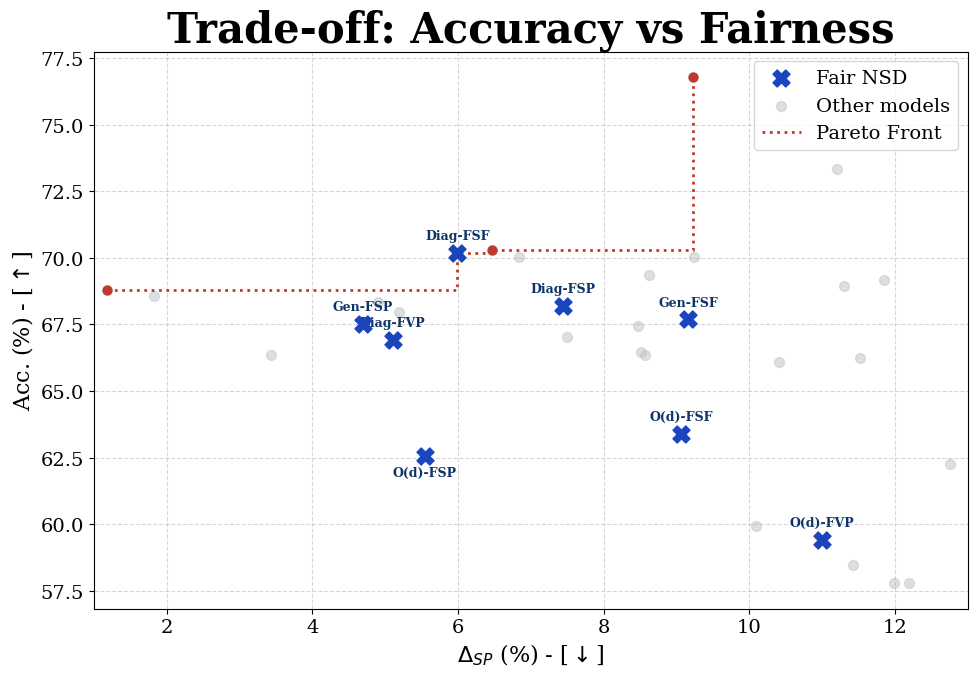

In [46]:
df_plot = df_raw.pivot_table(index=['Model', 'Model Display'], columns='MetricID', values='Value', aggfunc='mean').reset_index()

def is_strict_target(name):
    prefixes = ['spec', 'vect', 'poly']
    roots = ['dia', 'bun', 'gen']
    
    found_prefix = False
    for p in prefixes:
        if name.startswith(p):
            found_prefix = True
            break
            
    if not found_prefix:
        return False
        
    for r in roots:
        if r in name:
            return True
            
    return False

df_plot['is_mine'] = df_plot['Model'].apply(is_strict_target)

df_mine = df_plot[df_plot['is_mine']].copy()
df_others = df_plot[~df_plot['is_mine']].copy()

df_sorted = df_plot.sort_values(by='ind')
frontier = []
current_best_acc = -float('inf')

for _, row in df_sorted.iterrows():
    if row['acc'] > current_best_acc:
        frontier.append(row)
        current_best_acc = row['acc']
        
df_frontier = pd.DataFrame(frontier)

manual_offsets = {
    'Diag-FVP': (0, 10),
    'O(d)-FVP': (0, 10),
    'Gen-FVP': (0, 10),
    'Diag-FSP': (0, 10),
    'O(d)-FSP': (0, -15),
    'Gen-FSP': (0, 10),
    'Diag-FSF': (0, 10),
    'O(d)-FSF': (0, 10),
    'Gen-FSF': (0, 10)
}

plt.figure(figsize=(10, 7))

if not df_mine.empty:
    plt.scatter(df_mine['ind'], df_mine['acc'], 
                color="#1a45bc", marker='X', s=150, zorder=10, label='Fair NSD')
    
    for _, row in df_mine.iterrows():
        disp_name = row['Model Display']
        offset = manual_offsets.get(disp_name, (0, 10))
        
        plt.annotate(
            disp_name, 
            (row['ind'], row['acc']),
            xytext=offset, textcoords='offset points',
            ha='center', fontsize=9, fontweight='bold', color="#0e3466"
        )

plt.scatter(df_others['ind'], df_others['acc'], 
            color='#bdc3c7', alpha=0.5, s=50, label='Other models')

if not df_frontier.empty:
    plt.step(df_frontier['ind'], df_frontier['acc'], where='post',
             color='#c0392b', linestyle=':', linewidth=2, label='Pareto Front')
    
    plt.scatter(df_frontier['ind'], df_frontier['acc'], 
                color='#c0392b', s=40, zorder=5)

plt.xlabel(r'$\Delta_{SP}$ (%) - [$\downarrow$]')
plt.ylabel(r'Acc. (%) - [$\uparrow$]')
plt.title('Trade-off: Accuracy vs Fairness', fontweight='bold', size=30)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')

plt.xlim((1.,13))
plt.tight_layout()
plt.savefig('results/filter/figs/pareto.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [37]:
df_plot

MetricID,Model,Model Display,acc,dti,ind,is_mine
0,adversarial,adv-MLP,73.342773,31.080965,11.201961,False
1,bun,O(d)-NSD,62.255592,43.085804,12.749790,False
2,dia,Diag-NSD,58.480225,45.303737,11.415765,False
3,fairgnn,FairGNN,67.964329,32.769540,5.195113,False
4,fairsin,FairSIN,66.477724,36.218777,8.517027,False
5,fd_gat,Fair Drop,69.166130,33.033098,11.851498,False
6,fd_gcn,Fair Drop,66.040176,45.277882,29.946902,False
7,fd_sage,Fair Drop,68.786544,31.246111,1.186609,False
8,gat,GAT,57.788848,46.715873,11.986238,False
9,gcn,GCN,66.363734,36.212741,8.565826,False


In [26]:
df_raw

,Model,Model Display,MetricID,Value
0,Rej. Opt.,Log. Reg.,acc,65.346533
1,Rej. Opt.,Log. Reg.,ind,9.282053
2,Rej. Opt.,Log. Reg.,dti,35.875051
3,Rej. Opt.,XGBoost,acc,67.326730
4,Rej. Opt.,XGBoost,ind,6.307691
5,Rej. Opt.,XGBoost,dti,33.276561
6,Rej. Opt.,LightGBM,acc,65.346533
7,Rej. Opt.,LightGBM,ind,8.974358
8,Rej. Opt.,LightGBM,dti,35.796674
9,Rej. Opt.,MLP,acc,64.356434
